# Sweep di precisione in streaming

Notebook per analizzare come varia la stima al variare del parametro di precisione per `HyperLogLog++`, `HyperLogLog`, `LogLog` e `Probabilistic Counting`.

Il notebook usa i risultati nei namespace:
- `streaming_precision_sweep_hllpp`
- `streaming_precision_sweep_hll`
- `streaming_precision_sweep_ll`
- `streaming_precision_sweep_pc`

Le uscite principali sono:
- heatmap `parametro x rho` sull'errore relativo medio all'endpoint;
- confronto tipo A in scala lineare e log-log;
- confronto tipo B in scala lineare e log-log;
- tabella del parametro migliore per algoritmo e per `rho`.


In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Repository root non trovata: esegui il notebook dalla repo o da una sua sottocartella')

REPO = find_repo_root(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from scripts.streaming_precision_sweep_analysis import export_all

FIG_DIR = REPO / 'thesis' / 'figures' / 'results'
RESULTS_DIR = REPO / 'results'
REPO


PosixPath('/home/daniele/Dev/satp-cpp')

In [2]:
endpoint, best = export_all(REPO)

display(endpoint[['algorithm_label', 'param_name', 'param_value', 'rho', 'endpoint_mre']].sort_values(['algorithm_label', 'rho', 'param_value']))
display(best)

print('Figure esportate in:', FIG_DIR)
print('CSV di sintesi in:', RESULTS_DIR)


,algorithm_label,param_name,param_value,rho,endpoint_mre
6599,HyperLogLog,k,4,1,0.229197
7199,HyperLogLog,k,6,1,0.099677
7799,HyperLogLog,k,8,1,0.018927
4199,HyperLogLog,k,10,1,0.001963
4799,HyperLogLog,k,12,1,0.020834
...,...,...,...,...,...
12799,Probabilistic Counting,L,16,100,0.250185
13399,Probabilistic Counting,L,20,100,0.523830
13999,Probabilistic Counting,L,24,100,0.523830
14599,Probabilistic Counting,L,28,100,0.523830


,algorithm_label,param_name,param_value,rho,endpoint_mre
0,HyperLogLog,k,10,1,0.001963
1,HyperLogLog,k,16,10,0.003598
2,HyperLogLog,k,16,100,0.002704
3,HyperLogLog++,k,18,1,0.001326
4,HyperLogLog++,k,18,10,0.001561
5,HyperLogLog++,k,18,100,0.001119
6,LogLog,k,14,1,0.002709
7,LogLog,k,16,10,0.004044
8,LogLog,k,14,100,0.008168
9,Probabilistic Counting,L,20,1,0.864439


Figure esportate in: /home/daniele/Dev/satp-cpp/thesis/figures/results
CSV di sintesi in: /home/daniele/Dev/satp-cpp/results


## Heatmap di sintesi
La figura seguente riassume, per ciascun algoritmo, come cambia l'errore relativo medio all'endpoint al variare del parametro di precisione e di `rho`.


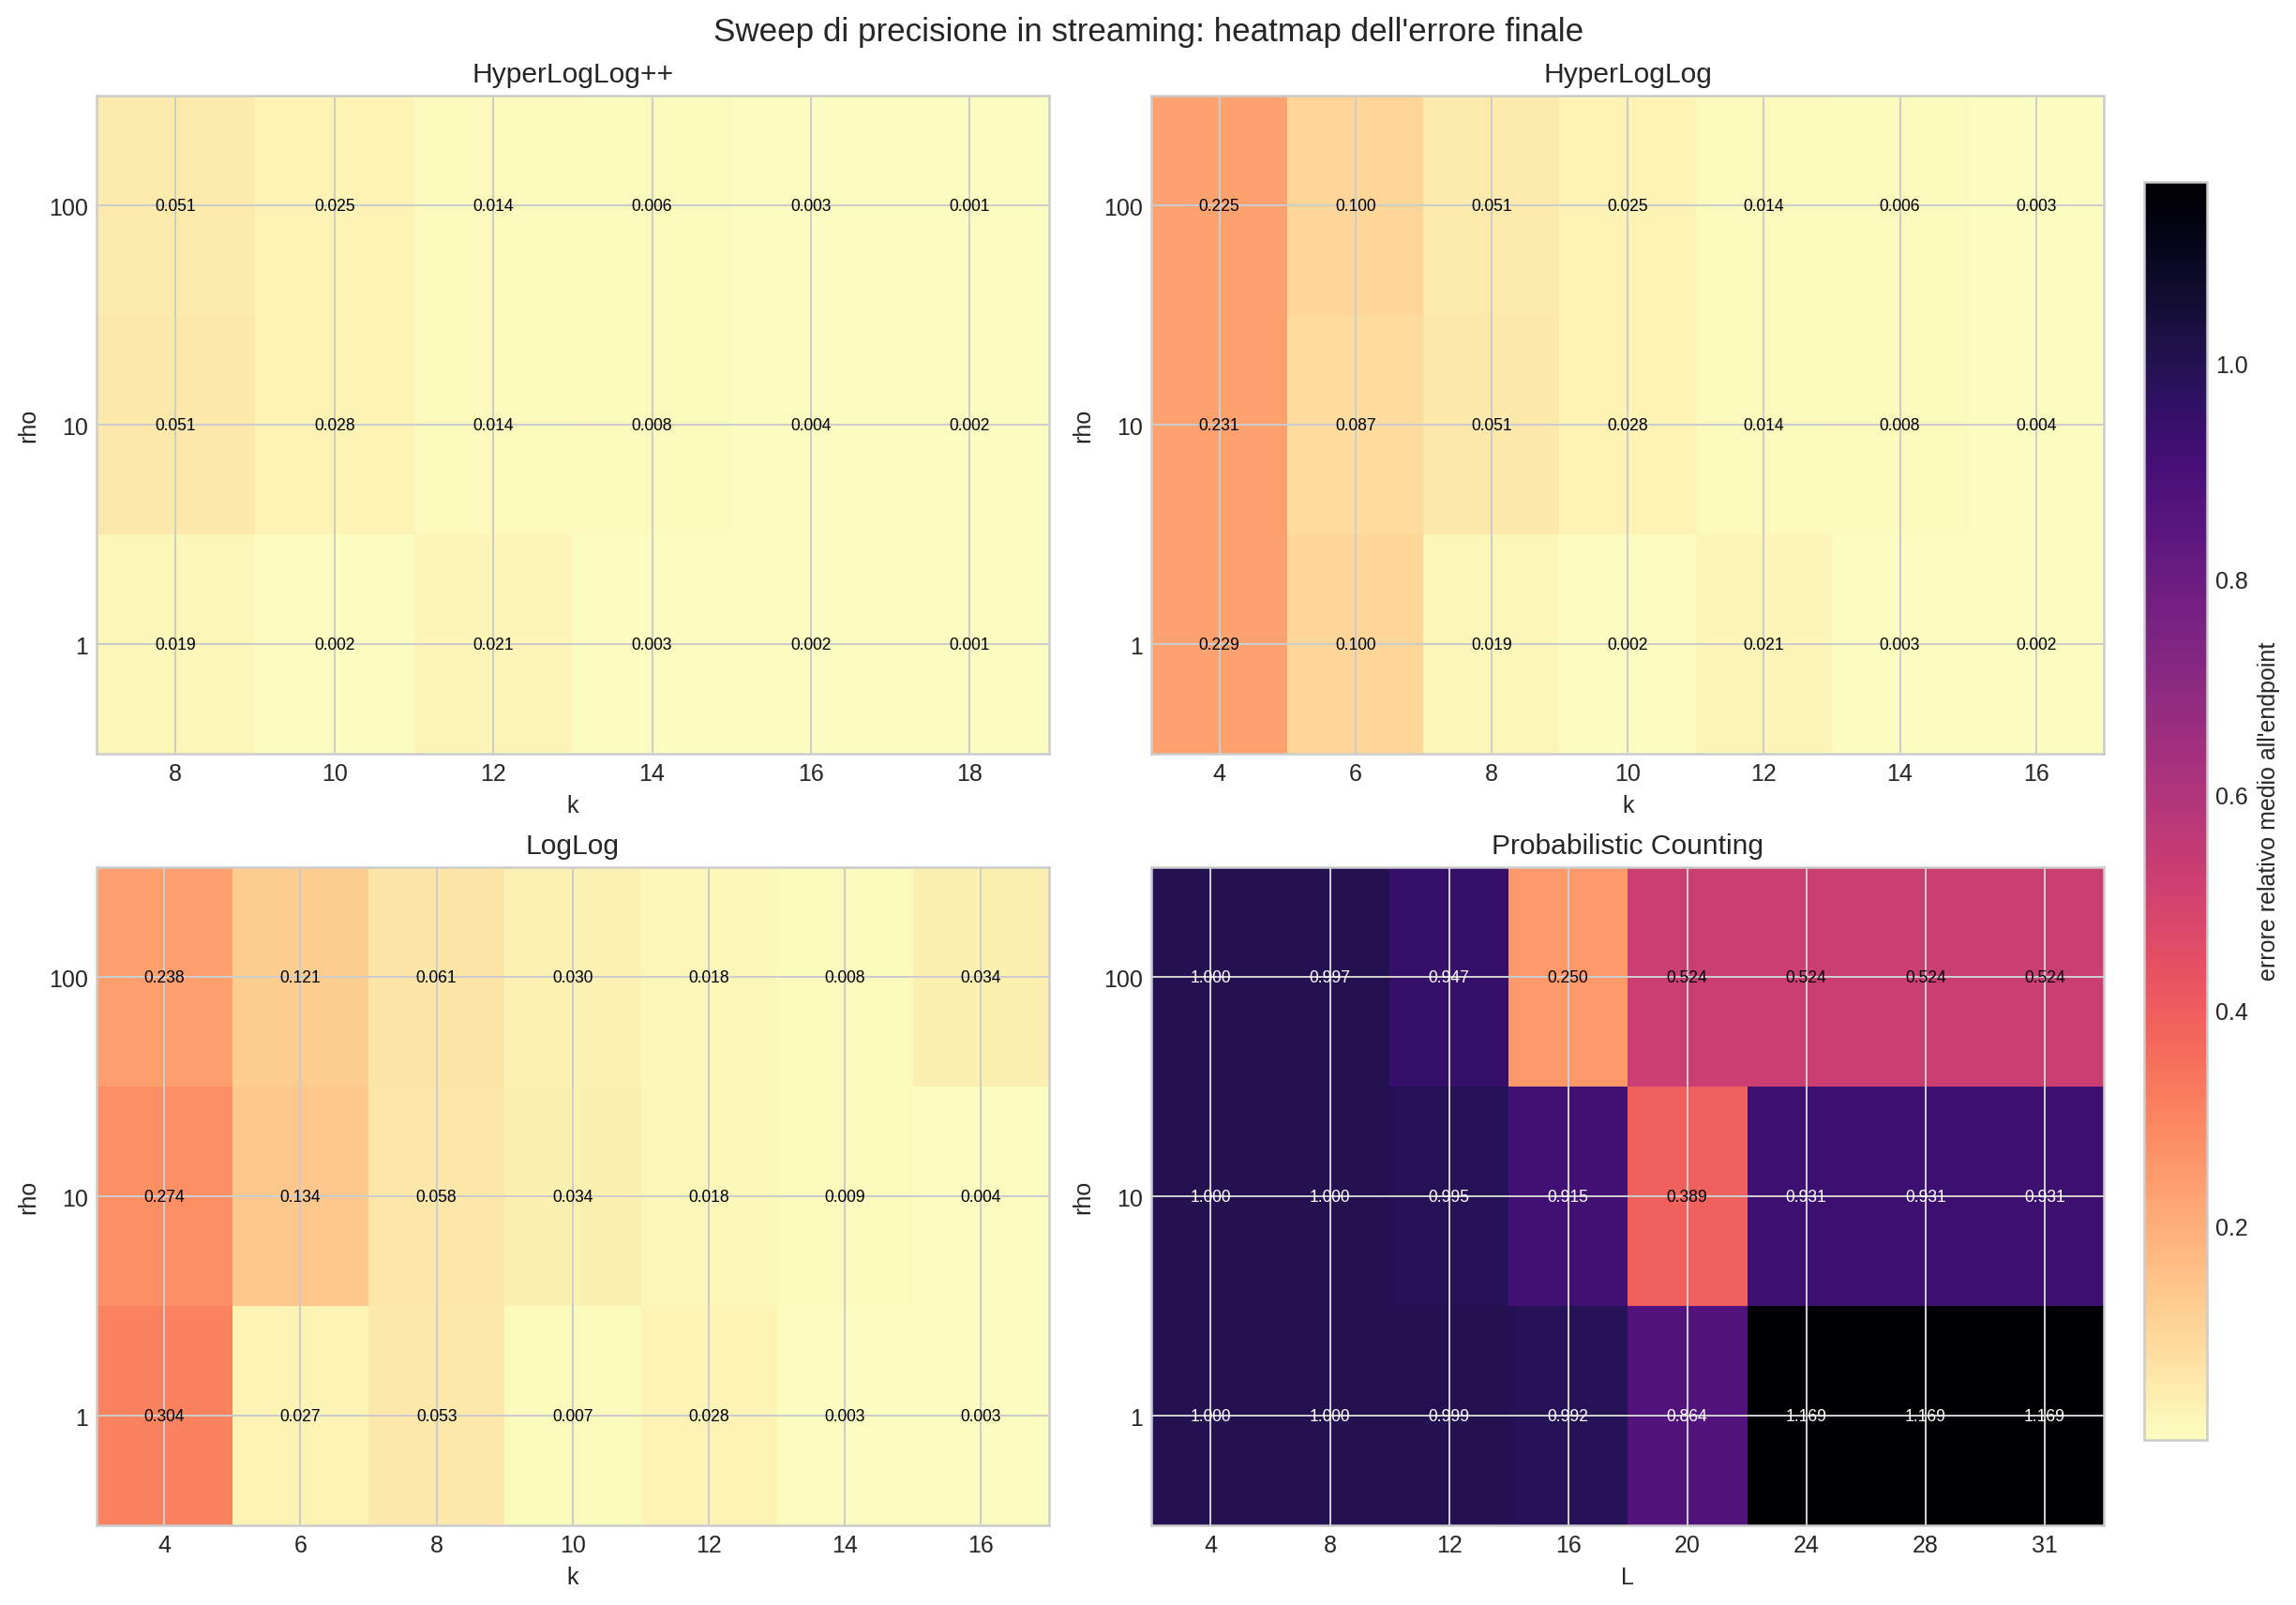

In [3]:
display(Image(filename=str(FIG_DIR / 'streaming_precision_sweep_endpoint_heatmaps.png')))


## Confronto tipo A
Per ogni algoritmo, le colonne corrispondono a `rho = 1, 10, 100`, mentre in ciascun pannello compare una curva per ogni valore del parametro di precisione.


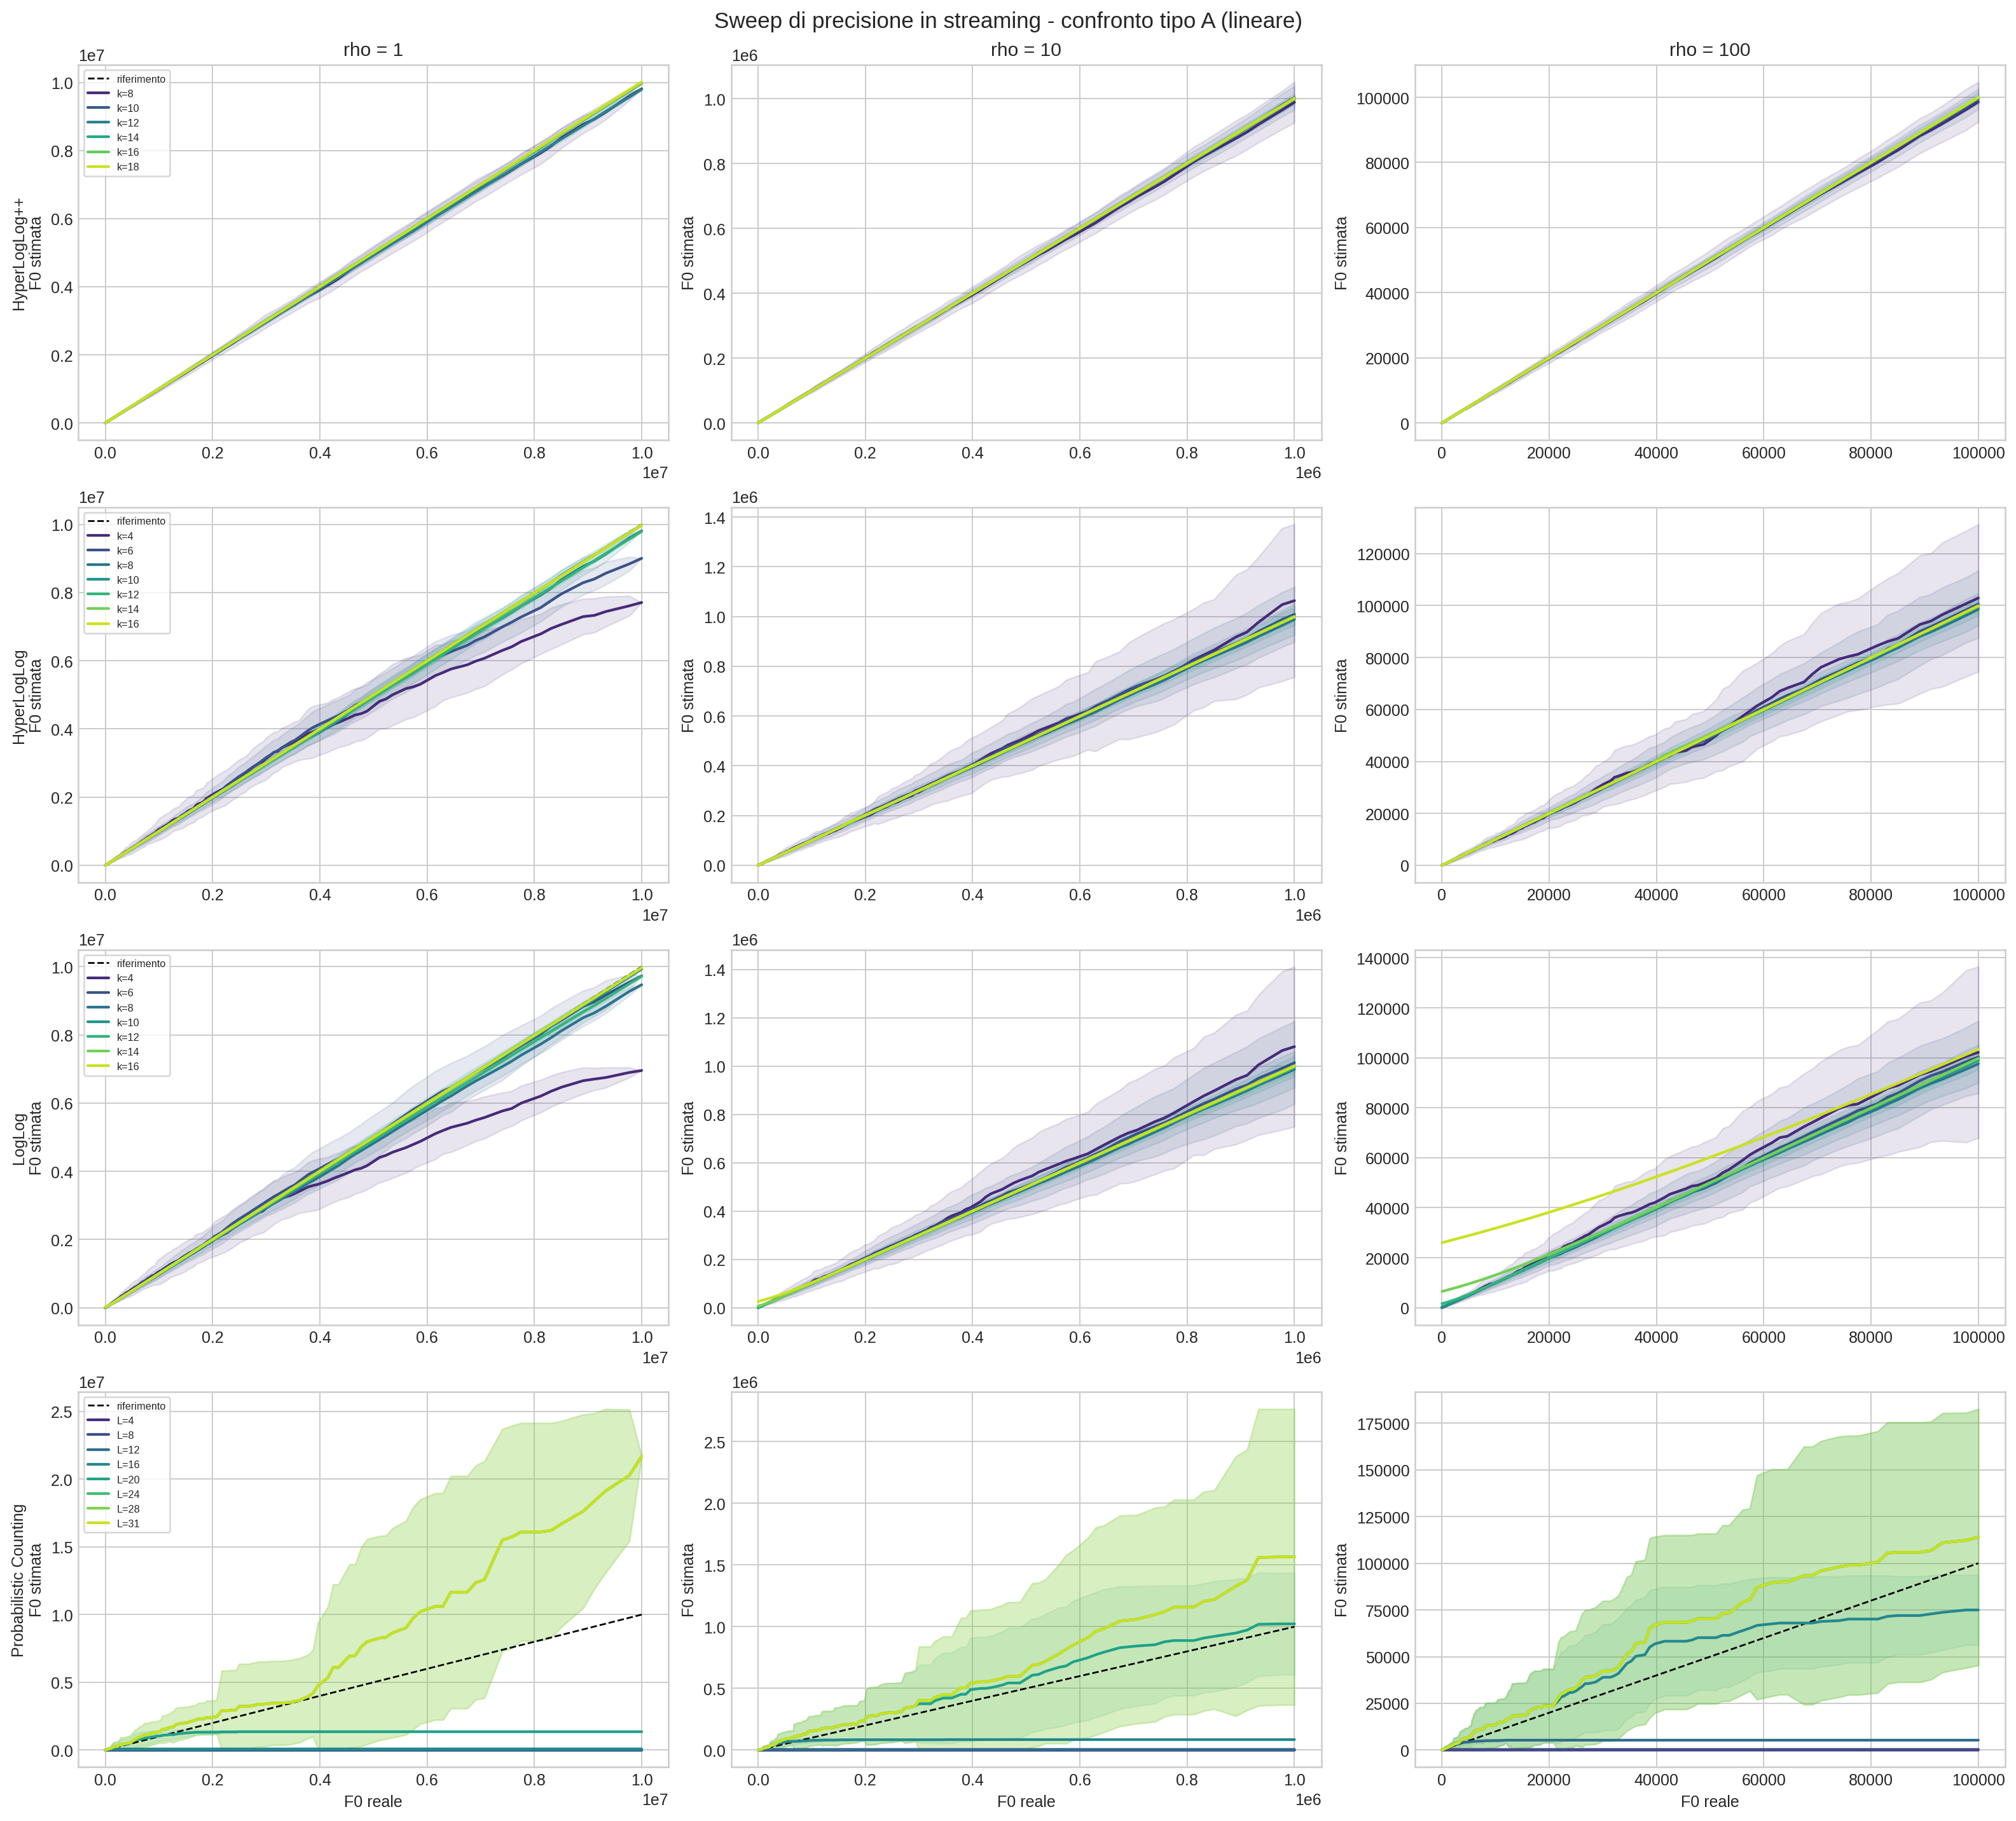

In [4]:
display(Image(filename=str(FIG_DIR / 'streaming_precision_sweep_typeA_grid_linear.png')))


## Confronto a cardinalità obiettivo fissata
Anche in questo caso le colonne corrispondono a `rho = 1, 10, 100`, mentre l'ascissa usa i valori obiettivo `F0*` adottati per l'interpolazione dei punti del capitolo 5.


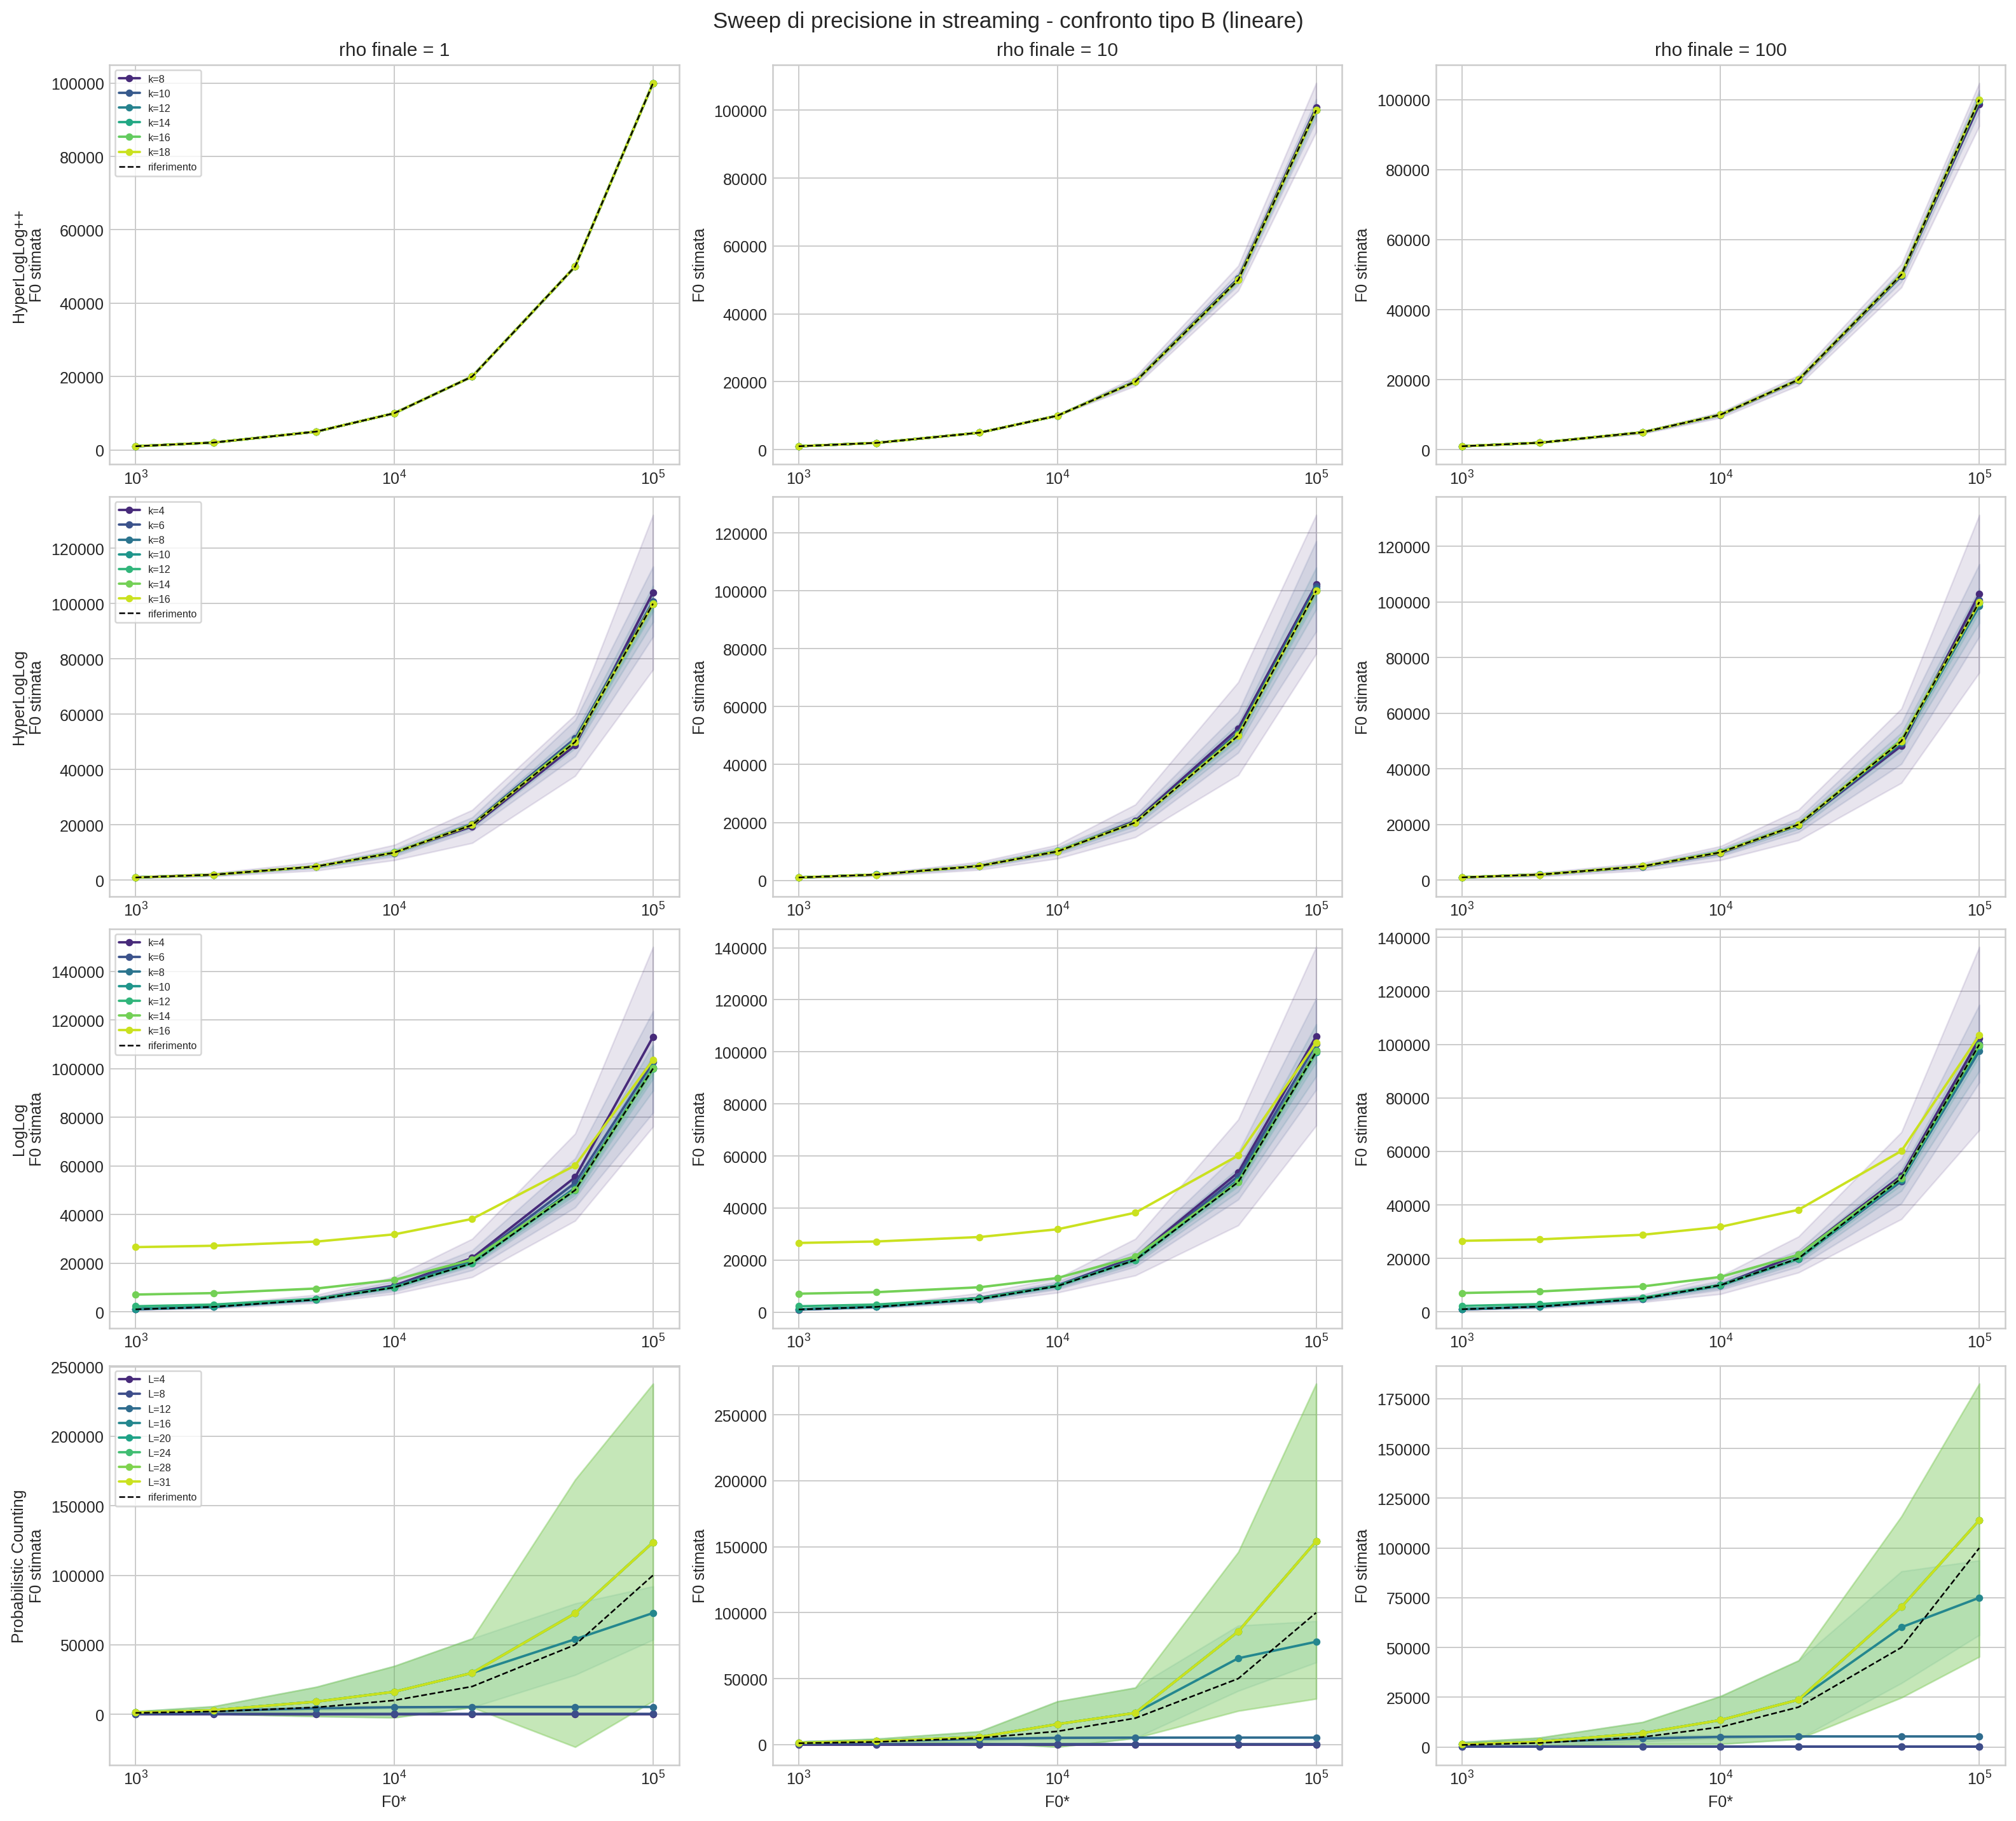

In [5]:
display(Image(filename=str(FIG_DIR / 'streaming_precision_sweep_typeB_grid_linear.png')))
